In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as   mcolors
from datataking import search_datadict_miyamura
from scipy import interpolate
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit

cd = "CDY163"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.47
# target_freq = 10.3875

In [2]:
def fit_waveform(time, data, x0=[2e-3,600], get_center=False, curve='gaussian', **kwargs):
    if curve=='gaussian':
        func = lambda x: x[0]*np.exp(-((time-x[1])/kwargs['sigma'])**2/2)
        cost_func = lambda x: np.linalg.norm(x[0]*np.exp(-((time-x[1])/kwargs['sigma'])**2/2) - data)
    elif curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="raisedcos":
        func = lambda x: x[0]*np.sin(np.pi*(time-x[1])/kwargs['T'])**2*(time<=kwargs['T']+x[1])*(x[1]<=time)
        cost_func = lambda x: np.linalg.norm(x[0]*np.sin(np.pi*(time-x[1])/kwargs['T'])**2*(time<=kwargs['T']+x[1])*(x[1]<=time) - data)
    elif curve=="anti_sech":
        func = lambda x: np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

def IQ_sym_(wave,time,start=0,stop=3000):
    wave_rev = np.flip(wave).conj()
    norm=np.sum(np.abs(wave)**2)**2
    m=0
    c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = wave*wave_rev_i
        mult_sum=np.sum(mult)
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    # plt.plot(np.arange(len(wave)), c)
    return m/norm

def target_overlap(wave, time, curve='sech'):
    wave = np.abs(wave) ### changed by Sunada
    wave_rev = np.flip(wave)
    if curve=='sech':
        target = 1 / np.cosh(const * (time-time[-1]/2))
    elif curve=="anti_sech":
        target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
    target = np.abs(target)
    norm = np.sum(np.abs(wave)**2) * (time[1] - time[0])
    norm_target  =np.sum(np.abs(target)**2) * (time[1] - time[0])
    m=0 ;c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = target*wave_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    return m / norm / norm_target

# symmetrical shape

In [3]:
name_dict = dict(
    data1 = dict(amp=0.1, date="2024-07-30", acquire_time="155906", params=dict(fit_start=30, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data2 = dict(amp=0.15, date="2024-07-30", acquire_time="172004", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data3 = dict(amp=0.2, date="2024-07-30", acquire_time="184132", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data4 = dict(amp=0.25, date="2024-07-30", acquire_time="200315", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data5 = dict(amp=0.3, date="2024-07-30", acquire_time="203720", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data6 = dict(amp=0.35, date="2024-07-30", acquire_time="211127", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data7 = dict(amp=0.4, date="2024-07-30", acquire_time="214535", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data8 = dict(amp=0.45, date="2024-07-30", acquire_time="070559", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data9 = dict(amp=0.5, date="2024-07-30", acquire_time="074131", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data10 = dict(amp=0.55, date="2024-07-30", acquire_time="081651", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data11 = dict(amp=0.5, date="2024-07-24", acquire_time="184355", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data11 = dict(amp=1.1, date="2024-05-30", acquire_time="043124", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data12 = dict(amp=1.2, date="2024-05-13", acquire_time="223813", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data125 = dict(amp=1.25, date="2023-12-27", acquire_time="041444", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data13 = dict(amp=1.075, date="2024-2-20", acquire_time="203046", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data14 = dict(amp=1.1, date="2023-12-27", acquire_time="102535", params=dict(fit_start=50, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data15 = dict(amp=1.125, date="2023-12-27", acquire_time="101913", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data15 = dict(amp=1.2, date="2023-12-27", acquire_time="035436", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data16 = dict(amp=1.3, date="2024-2-20", acquire_time="195024", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data17 = dict(amp=1.4, date="2023-12-27", acquire_time="045145", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data18 = dict(amp=1.45, date="2023-12-27", acquire_time="052020", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data181 = dict(amp=1.48, date="2023-12-27", acquire_time="054855", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data182 = dict(amp=1.49, date="2023-12-27", acquire_time="061732", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data19 = dict(amp=1.3, date="2023-12-27", acquire_time="111410", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
)

# Generating Control Pulses

In [4]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

0.1 2024-07-30 155906
0.15 2024-07-30 172004
0.2 2024-07-30 184132
0.25 2024-07-30 200315
0.3 2024-07-30 203720
0.35 2024-07-30 211127
0.4 2024-07-30 214535


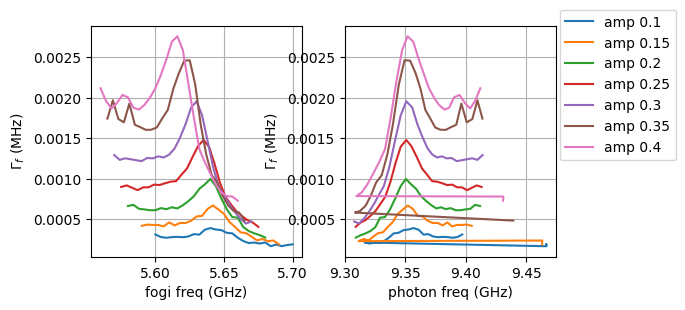

{'a0': 0, 'a2': 0.019220362658817436, 'a4': 2.2941915034380145e-09, 'a6': 1.511235581119763e-12, 'a8': 4.198641434527417e-12, 'a10': 2.563305123715054e-11}


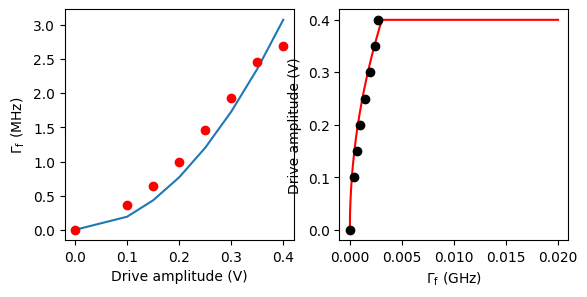

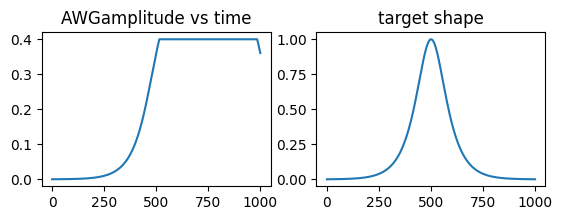

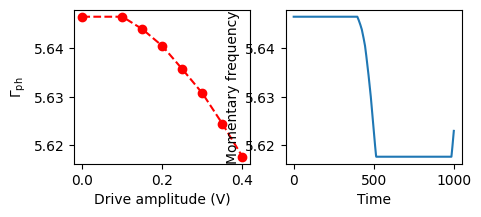

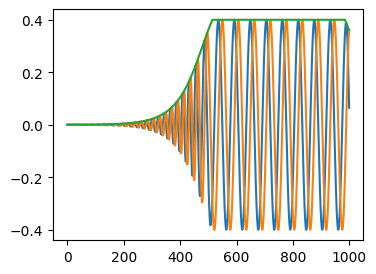

In [5]:
form = "sech"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.6, target_freq, duration, const=const, form=form, tr=False)

## save

In [18]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
duration = 1000
for target_freq in [9.33, 9.35, 9.37]:
    control_pulse = dataobj.generate_control_pulse(5.53, target_freq, duration, const=const, form=form, plot=False, tr=False)
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd])
        writer.save_text("target_shape.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.008741772537603332, 'a4': 1.8545165403338615e-12, 'a6': 5.211830966800335e-12, 'a8': 3.6490810373379645e-12, 'a10': 1.4341194898292997e-11}
{'a0': 0, 'a2': 0.019220362658817436, 'a4': 2.2941915034380145e-09, 'a6': 1.511235581119763e-12, 'a8': 4.198641434527417e-12, 'a10': 2.563305123715054e-11}
{'a0': 0, 'a2': 0.01418301795409227, 'a4': 0.0, 'a6': 2.531308496145357e-14, 'a8': 7.1951333779907145e-12, 'a10': 2.965894196904628e-11}


# Photon shaping analysis

In [23]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-07-31", acquire_time="002524"),
    data1 = dict(target_freq=9.35, date="2024-07-31", acquire_time="003213"),
    # data2 = dict(target_freq=9.37, date="2024-07-31", acquire_time="002903"),
)

symmetry 0.8283922513065525, overlap 0.9927790516739168


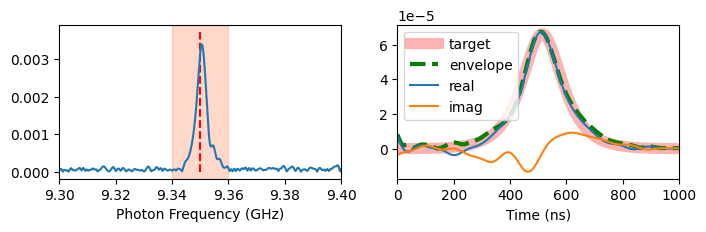

In [24]:
passing_band = 0.01
duration=1000
cd = "CDY163"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.3, 9.4)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
plt.legend()

phase substraction

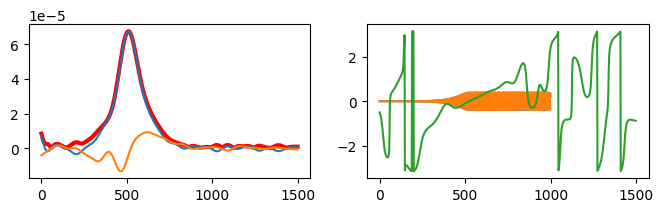

In [25]:
# original
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

corrected photon shaping

In [33]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data1 = dict(target_freq=9.35, date="2024-07-31", acquire_time="004240"),
    # data2 = dict(target_freq=10.3825, date="2024-07-26", acquire_time="081627"),
    # data3 = dict(target_freq=10.3850, date="2024-07-26", acquire_time="082316"),
)


symmetry 0.9306947241325939, overlap 0.987610267391856


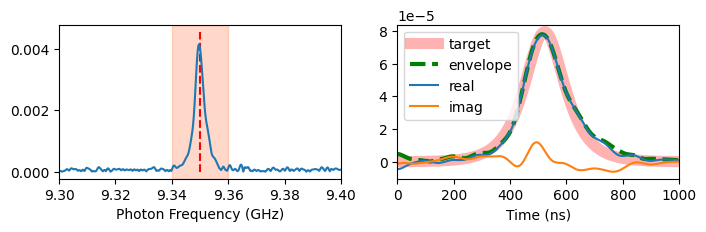

In [34]:
passing_band = 0.01
duration=1000
cd = "CDY163"
data_path = f"D:\\K_Sunada\\result\\{cd}"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.3, 9.4)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
plt.legend()


fogi pulse generation for absoption

In [30]:
date = "2024-07-31"
acquire_time="004209"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )